  # 01 — Brent crude oil in euros
  Download daily Brent prices (USD/barrel) and the EUR/USD exchange rate from FRED.

In [8]:
# Import the libraries
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Download the Brent oil price (USD per barrel) from FRED and save it
brent = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU", na_values=".")
brent.columns = ["date", "brent_usd"]
brent.to_csv("../data/raw/brent_usd.csv", index=False)

# Download the EUR/USD exchange rate (dollars per 1 euro) from FRED and save it
fx = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXUSEU", na_values=".")
fx.columns = ["date", "usd_per_eur"]
fx.to_csv("../data/raw/usd_per_eur.csv", index=False)

# Check how many days we downloaded
print(len(brent), "days of Brent data")
print(len(fx), "days of exchange rate data")

10270 days of Brent data
7235 days of exchange rate data


## Brent in euros per litre, weekly average

In [10]:
# Load the saved data
brent = pd.read_csv("../data/raw/brent_usd.csv")
fx = pd.read_csv("../data/raw/usd_per_eur.csv")

# Merge both tables by date and remove days with missing values
df = pd.merge(brent, fx, on="date")
df = df.dropna()

# Turn the date column into real dates and keep data from 2019 onwards
df["date"] = pd.to_datetime(df["date"])
df = df[df["date"] >= "2019-01-01"]

# Convert Brent to euros per barrel, then to euros per litre (1 barrel = 158.987 litres)
df["brent_eur_bbl"] = df["brent_usd"] / df["usd_per_eur"]
df["brent_eur_litre"] = df["brent_eur_bbl"] / 158.987

# Calculate weekly averages and save them
weekly = df.resample("W", on="date").mean()
weekly.to_csv("../data/processed/brent_eur_weekly.csv")

# Check the number of weeks and show the last 5
print(len(weekly), "weeks")
weekly.tail()

404 weeks


,brent_usd,usd_per_eur,brent_eur_bbl,brent_eur_litre
date,,,,
2026-08-30,89.7300,1.164820,77.033619,0.484528
2026-09-06,99.0925,1.160650,85.374572,0.536991
2026-09-13,113.6675,1.162175,97.807516,0.615192
2026-09-20,124.1460,1.151440,107.811481,0.678115
2026-09-27,117.0840,1.141360,102.587463,0.645257


## Chart: Brent price in euros per litre

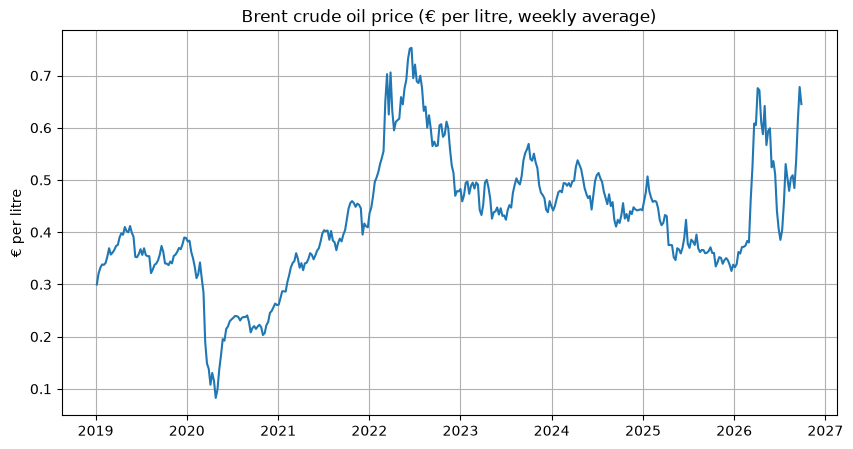

In [11]:
# Draw the weekly Brent price in euros per litre
plt.figure(figsize=(10, 5))
plt.plot(weekly.index, weekly["brent_eur_litre"])
plt.title("Brent crude oil price (€ per litre, weekly average)")
plt.ylabel("€ per litre")
plt.grid(True)

# Save the chart in the figures folder and show it
plt.savefig("../figures/brent_eur_litre.png")
plt.show()